In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tqdm import tqdm
import glob
import os
# Force TensorFlow to use CPU
tf.config.set_visible_devices([], 'GPU')

In [2]:
# --- 1. Configuration ---
RAW_DATA_DIR = "/Users/pg/Documents/Segmentation Research/Activity Recognition/src/WiFi-Signal-Processing-HAR/data"
PCA_COMPONENTS = 50
EPOCHS = 50 
BATCH_SIZE = 32
VALID_ACTIVITIES = ['sitting', 'walking', 'standing', 'sleeping', 'falling']

# *** NEW: Temporal windowing parameters ***
WINDOW_SIZE = 50  # Number of consecutive timestamps per sample
STRIDE = 50  # No overlap between windows
USE_MAGNITUDE = True

# ALL 20250727 sessions for training (55 files)
train_sessions_files = [
    # Falling (15 files)
    'esp32_csi_falling_20250727_131141', 'esp32_csi_falling_20250727_131346',
    'esp32_csi_falling_20250727_131551', 'esp32_csi_falling_20250727_131757',
    'esp32_csi_falling_20250727_132002', 'esp32_csi_falling_20250727_132210',
    'esp32_csi_falling_20250727_132417', 'esp32_csi_falling_20250727_132620',
    'esp32_csi_falling_20250727_132826', 'esp32_csi_falling_20250727_133043',
    'esp32_csi_falling_20250727_164609', 'esp32_csi_falling_20250727_164810',
    'esp32_csi_falling_20250727_165013', 'esp32_csi_falling_20250727_165221',
    'esp32_csi_falling_20250727_165423',
    
    # Sitting (10 files)
    'esp32_csi_sitting_20250727_155647', 'esp32_csi_sitting_20250727_155903',
    'esp32_csi_sitting_20250727_160108', 'esp32_csi_sitting_20250727_160311',
    'esp32_csi_sitting_20250727_160513', 'esp32_csi_sitting_20250727_160718',
    'esp32_csi_sitting_20250727_160929', 'esp32_csi_sitting_20250727_161310',
    'esp32_csi_sitting_20250727_161517', 'esp32_csi_sitting_20250727_161725',
    
    # Sleeping (10 files)
    'esp32_csi_sleeping_20250727_161957', 'esp32_csi_sleeping_20250727_162235',
    'esp32_csi_sleeping_20250727_162437', 'esp32_csi_sleeping_20250727_162727',
    'esp32_csi_sleeping_20250727_162938', 'esp32_csi_sleeping_20250727_163213',
    'esp32_csi_sleeping_20250727_163416', 'esp32_csi_sleeping_20250727_163620',
    'esp32_csi_sleeping_20250727_163829', 'esp32_csi_sleeping_20250727_164127',
    
    # Standing (10 files)
    'esp32_csi_standing_20250727_153438', 'esp32_csi_standing_20250727_153641',
    'esp32_csi_standing_20250727_153848', 'esp32_csi_standing_20250727_154050',
    'esp32_csi_standing_20250727_154314', 'esp32_csi_standing_20250727_154516',
    'esp32_csi_standing_20250727_154720', 'esp32_csi_standing_20250727_155036',
    'esp32_csi_standing_20250727_155242', 'esp32_csi_standing_20250727_155444',
    
    # Walking (10 files)
    'esp32_csi_walking_20250727_150913', 'esp32_csi_walking_20250727_151117',
    'esp32_csi_walking_20250727_151320', 'esp32_csi_walking_20250727_151522',
    'esp32_csi_walking_20250727_151726', 'esp32_csi_walking_20250727_151943',
    'esp32_csi_walking_20250727_152148', 'esp32_csi_walking_20250727_152400',
    'esp32_csi_walking_20250727_152603', 'esp32_csi_walking_20250727_152811'
]

# Validation sessions from 20250728 (10 files)
val_sessions_files = [
    'esp32_csi_falling_20250728_114422', 'esp32_csi_falling_20250728_115449',
    'esp32_csi_sitting_20250728_133017', 'esp32_csi_sitting_20250728_132048',
    'esp32_csi_sleeping_20250728_122928', 'esp32_csi_sleeping_20250728_125027',
    'esp32_csi_standing_20250728_134638', 'esp32_csi_standing_20250728_142621',
    'esp32_csi_walking_20250728_150750', 'esp32_csi_walking_20250728_143333'
]

print(f"Training sessions: {len(train_sessions_files)} files (all from 20250727)")
print(f"Validation sessions: {len(val_sessions_files)} files (all from 20250728)")
print(f"\nWindow size: {WINDOW_SIZE} timestamps, Stride: {STRIDE} timestamps")

Training sessions: 55 files (all from 20250727)
Validation sessions: 10 files (all from 20250728)

Window size: 50 timestamps, Stride: 50 timestamps


In [3]:
# --- 2. Data Loading and Cleaning Function ---
def load_and_clean_sessions(file_list, data_dir):
    """Loads, concatenates, and cleans a specific list of session files."""
    df_list = []
    for filename in tqdm(file_list, desc=f"Loading files for set"):
        file_path = os.path.join(data_dir, f"{filename}.csv")
        if not os.path.exists(file_path):
            print(f"[Warning] File not found: {filename}. Skipping.")
            continue
        try:
            activity_label = filename.split('_')[2]
            if activity_label in VALID_ACTIVITIES:
                temp_df = pd.read_csv(file_path)
                temp_df['activity'] = activity_label
                temp_df['session'] = filename
                df_list.append(temp_df)
        except Exception as e:
            print(f"Could not process {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    master_df = pd.concat(df_list, ignore_index=True)
    
    # Cleaning Steps
    null_subcarriers = list(range(27, 37))
    cleaned = master_df[~master_df['subcarrier_index'].isin(null_subcarriers)]
    
    magnitude_sum = cleaned.groupby(['session', 'timestamp'])['magnitude'].sum()
    dropout_indices = magnitude_sum[magnitude_sum == 0].index
    cleaned = cleaned.set_index(['session', 'timestamp']).drop(index=dropout_indices).reset_index()
    
    return cleaned

In [4]:
# --- 3. Create Training and Validation DataFrames ---
print("--- Creating Training DataFrame ---")
train_df = load_and_clean_sessions(train_sessions_files, RAW_DATA_DIR)

print("\n--- Creating Validation DataFrame ---")
val_df = load_and_clean_sessions(val_sessions_files, RAW_DATA_DIR)

if train_df.empty or val_df.empty:
    print("\n[ERROR] Training or validation dataframe is empty. Please check your filenames and data directory.")

--- Creating Training DataFrame ---


Loading files for set: 100%|██████████| 55/55 [00:01<00:00, 52.80it/s]



--- Creating Validation DataFrame ---


Loading files for set: 100%|██████████| 10/10 [00:00<00:00, 45.36it/s]


In [5]:
# --- 4. Temporal Windowing Approach ---
def create_temporal_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Create temporal windows from CSI data.
    Each window contains WINDOW_SIZE consecutive timestamps.
    """
    windows = []
    labels = []
    expected_subcarriers = 52  # After removing null subcarriers
    
    # Process each session separately (don't mix sessions)
    for session_name, session_df in tqdm(df.groupby('session'), desc="Creating windows"):
        session_df = session_df.sort_values('timestamp')
        timestamps = sorted(session_df['timestamp'].unique())
        
        # Create windows with sliding window approach
        for i in range(0, len(timestamps) - window_size + 1, stride):
            window_timestamps = timestamps[i:i + window_size]
            window_data = session_df[session_df['timestamp'].isin(window_timestamps)]
            
            # Create feature matrix: (num_timestamps, num_subcarriers)
            window_matrix = []
            for ts in window_timestamps:
                ts_data = window_data[window_data['timestamp'] == ts].sort_values('subcarrier_index')
                
                if USE_MAGNITUDE:
                    features = ts_data['magnitude'].values
                else:
                    features = np.column_stack([ts_data['I'].values, ts_data['Q'].values]).flatten()
                
                # Pad if needed
                if len(features) < expected_subcarriers:
                    features = np.pad(features, (0, expected_subcarriers - len(features)), mode='constant')
                elif len(features) > expected_subcarriers:
                    features = features[:expected_subcarriers]
                
                window_matrix.append(features)
            
            # Only add if we have complete data
            if len(window_matrix) == window_size:
                windows.append(np.array(window_matrix))
                labels.append(session_df['activity'].iloc[0])
    
    return np.array(windows), np.array(labels)

print("\n=== Creating Temporal Windows ===")
X_train, y_train_raw = create_temporal_windows(train_df, window_size=WINDOW_SIZE, stride=STRIDE)
X_val, y_val_raw = create_temporal_windows(val_df, window_size=WINDOW_SIZE, stride=STRIDE)

print(f"\nWindow shape: {X_train.shape}")
print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}")
print(f"Format: (samples, timestamps={WINDOW_SIZE}, subcarriers={X_train.shape[2]})")


=== Creating Temporal Windows ===


Creating windows: 100%|██████████| 10/10 [00:02<00:00,  4.15it/s]


Window shape: (1439, 50, 52)
Train samples: 1439, Val samples: 280
Format: (samples, timestamps=50, subcarriers=52)


In [6]:
# --- 5. Normalize and Encode Labels ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

print("\n=== Encoding Labels ===")
le = LabelEncoder()
le.fit(np.concatenate([y_train_raw, y_val_raw]))
class_names = list(le.classes_)
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)

print(f"Classes: {class_names}")
print(f"\nClass distribution:")
print("Train:", {name: count for name, count in zip(*np.unique(y_train_raw, return_counts=True))})
print("Val:", {name: count for name, count in zip(*np.unique(y_val_raw, return_counts=True))})

# Normalize data
print("\n=== Normalizing Data ===")
scaler = StandardScaler()
n_samples_train, n_timestamps, n_features = X_train.shape
n_samples_val = X_val.shape[0]

X_train_reshaped = X_train.reshape(-1, n_features)
X_val_reshaped = X_val.reshape(-1, n_features)

X_train_norm = scaler.fit_transform(X_train_reshaped).reshape(n_samples_train, n_timestamps, n_features)
X_val_norm = scaler.transform(X_val_reshaped).reshape(n_samples_val, n_timestamps, n_features)

print(f"Normalized shape - Train: {X_train_norm.shape}, Val: {X_val_norm.shape}")

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights: {class_weight_dict}")


=== Encoding Labels ===
Classes: ['falling', 'sitting', 'sleeping', 'standing', 'walking']

Class distribution:
Train: {'falling': 363, 'sitting': 282, 'sleeping': 244, 'standing': 280, 'walking': 270}
Val: {'falling': 44, 'sitting': 71, 'sleeping': 58, 'standing': 60, 'walking': 47}

=== Normalizing Data ===
Normalized shape - Train: (1439, 50, 52), Val: (280, 50, 52)

Class weights: {0: 0.7928374655647383, 1: 1.0205673758865248, 2: 1.1795081967213115, 3: 1.0278571428571428, 4: 1.065925925925926}


In [7]:
# --- 6. Build Model for Temporal Sequences ---
def build_temporal_model(input_shape, num_classes):
    """
    CNN-LSTM model for temporal CSI sequences.
    Input shape: (timesteps, features)
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # CNN layers to extract spatial features
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.4),
        
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.4),
        
        # LSTM layers to learn temporal patterns
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
        layers.Dropout(0.5),
        
        # Dense classification layers
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build model
input_shape = (X_train_norm.shape[1], X_train_norm.shape[2])
print(f"\nModel input shape: {input_shape}")
print(f"  - Timesteps: {input_shape[0]}")
print(f"  - Features per timestep: {input_shape[1]}")

model = build_temporal_model(input_shape, num_classes=len(class_names))
model.summary()


Model input shape: (50, 52)
  - Timesteps: 50
  - Features per timestep: 52


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,573 (584.27 KB)

 Trainable params: 149,189 (582.77 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# --- 7. Train the Model ---
print("\nStarting model training...")

# FIX: Monitor val_accuracy instead of val_loss
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',  # Changed from 'val_loss'
    patience=10,
    restore_best_weights=True,
    mode='max',  # Maximize accuracy
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.2%}")


Starting model training...
Epoch 1/50
45/45 - 2s - 51ms/step - accuracy: 0.4183 - loss: 1.2801 - val_accuracy: 0.1643 - val_loss: 1.7953 - learning_rate: 0.0010
Epoch 2/50
45/45 - 1s - 14ms/step - accuracy: 0.4760 - loss: 1.1005 - val_accuracy: 0.1750 - val_loss: 2.1590 - learning_rate: 0.0010
Epoch 3/50
45/45 - 1s - 18ms/step - accuracy: 0.5059 - loss: 1.0350 - val_accuracy: 0.1607 - val_loss: 5.1727 - learning_rate: 0.0010
Epoch 4/50
45/45 - 1s - 17ms/step - accuracy: 0.5768 - loss: 0.9383 - val_accuracy: 0.2250 - val_loss: 4.4674 - learning_rate: 0.0010
Epoch 5/50
45/45 - 1s - 16ms/step - accuracy: 0.6372 - loss: 0.8493 - val_accuracy: 0.2214 - val_loss: 6.0221 - learning_rate: 0.0010
Epoch 6/50

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45/45 - 1s - 17ms/step - accuracy: 0.6838 - loss: 0.7711 - val_accuracy: 0.2143 - val_loss: 8.8809 - learning_rate: 0.0010
Epoch 7/50
45/45 - 1s - 17ms/step - accuracy: 0.7234 - loss: 0.6555 - val_accuracy: 0.2143 


Evaluating model performance on unseen validation sessions...


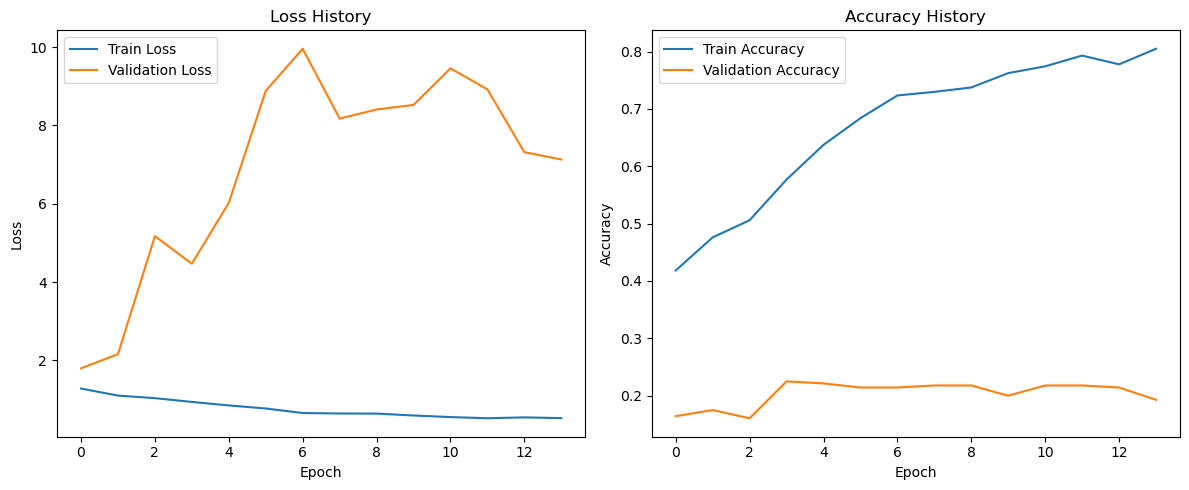

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


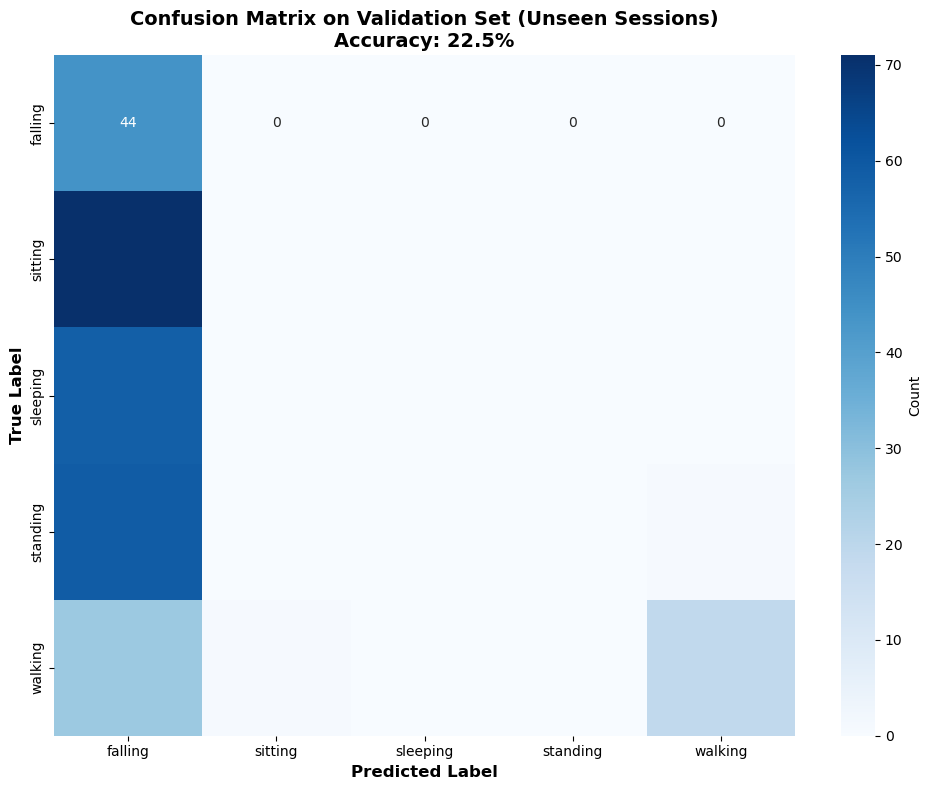


=== CONFUSION MATRIX GUIDE ===
Each ROW represents the TRUE label
Each COLUMN represents the PREDICTED label

Total validation samples: 280
Correctly classified: 63 (22.5%)
Misclassified: 217 (77.5%)

=== PER-CLASS BREAKDOWN ===
   falling:   44/  44 correct (100.0%)
   sitting:    0/  71 correct (  0.0%)
  sleeping:    0/  58 correct (  0.0%)
  standing:    0/  60 correct (  0.0%)
   walking:   19/  47 correct ( 40.4%)

Classification Report on Validation Set (Unseen Sessions):

              precision    recall  f1-score   support

     falling       0.17      1.00      0.29        44
     sitting       0.00      0.00      0.00        71
    sleeping       0.00      0.00      0.00        58
    standing       0.00      0.00      0.00        60
     walking       0.95      0.40      0.57        47

    accuracy                           0.23       280
   macro avg       0.22      0.28      0.17       280
weighted avg       0.19      0.23      0.14       280



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
# --- 8. Evaluate the Model ---
print("\nEvaluating model performance on unseen validation sessions...")

# --- Plot training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion Matrix and Report on the Validation Set ---
preds = np.argmax(model.predict(X_val), axis=1)

# Calculate confusion matrix with correct orientation
# Row = True labels, Column = Predicted labels
cm = confusion_matrix(y_val, preds)

# Create detailed confusion matrix plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix on Validation Set (Unseen Sessions)\nAccuracy: {:.1%}".format(np.mean(preds == y_val)), 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print confusion matrix interpretation
print("\n=== CONFUSION MATRIX GUIDE ===")
print("Each ROW represents the TRUE label")
print("Each COLUMN represents the PREDICTED label")
print(f"\nTotal validation samples: {len(y_val)}")
print(f"Correctly classified: {np.sum(preds == y_val)} ({np.mean(preds == y_val):.1%})")
print(f"Misclassified: {np.sum(preds != y_val)} ({np.mean(preds != y_val):.1%})")

print("\n=== PER-CLASS BREAKDOWN ===")
for i, class_name in enumerate(class_names):
    true_count = np.sum(y_val == i)
    correct_count = cm[i, i]
    accuracy = correct_count / true_count if true_count > 0 else 0
    print(f"{class_name:>10s}: {correct_count:4d}/{true_count:4d} correct ({accuracy:6.1%})")

print("\nClassification Report on Validation Set (Unseen Sessions):\n")
print(classification_report(y_val, preds, target_names=class_names))